# Verifoto Training Pipeline
## Complete workflow: GitHub → Colab → Training → Results → GitHub



**Workflow:**
1. Configure experiment parameters
2. Setup environment and load data
3. Train model
4. Analyze and visualize results
5. Backup to Drive and push to GitHub

In [2]:
# ============================================================================
# EXPERIMENT CONFIGURATION - Edit these for each run
# ============================================================================

EXPERIMENT_NAME = "2026-03-13_noise_high_pass"  # Unique name for this experiment
DATASET_NAME = "platsim_ar_pico_banana_9gb-V_highpass"     # Dataset folder name in Drive
CONFIG_FILE = "convnext_v8.yaml"                 # Config file to use (in configs/)

# Optional: GitHub token for pushing results (leave empty to skip push)
from google.colab import userdata
GITHUB_TOKEN = userdata.get('GH_T')

# ============================================================================
# Derived paths (don't edit)
# ============================================================================
DATASET_ROOT = f"/content/drive/MyDrive/DatasetVerifoto/images/{DATASET_NAME}"
CHECKPOINT_DIR = "/content/drive/MyDrive/verifoto_checkpoints"
BACKUP_DIR = f"/content/drive/MyDrive/verifoto_results/{EXPERIMENT_NAME}"
OUTPUT_DIR = f"outputs/runs/{EXPERIMENT_NAME}"
CONFIG_PATH = f"configs/{CONFIG_FILE}"

print("✓ Experiment configured:")
print(f"  Name: {EXPERIMENT_NAME}")
print(f"  Dataset: {DATASET_NAME}")
print(f"  Config: {CONFIG_FILE}")


✓ Experiment configured:
  Name: 2026-03-13_noise_high_pass
  Dataset: platsim_ar_pico_banana_9gb-V_highpass
  Config: convnext_v8.yaml


---
## 🔧 ENVIRONMENT SETUP


In [3]:
# Check GPU availability
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  WARNING: No GPU detected! Training will be very slow!")


GPU Available: True
GPU Name: NVIDIA A100-SXM4-40GB
GPU Memory: 42.41 GB


In [4]:
# ============================================================================
# GIT BRANCH CONFIGURATION
# ============================================================================
# Choose which branch to use for training
GIT_BRANCH = "develop-training"  # Options: "main", "develop", "develop-training", etc.

# Clone repository and install dependencies
%cd /content
!git clone -b {GIT_BRANCH} https://github.com/valerio-lorenti-ai/verifoto-dl.git
%cd verifoto-dl
!git pull origin {GIT_BRANCH}  # Get latest changes from selected branch

# Verify branch and show latest commit
print("\n" + "="*80)
print("GIT REPOSITORY INFO")
print("="*80)
!git branch --show-current
!git log -1 --oneline
print("="*80)

!pip install -q -r requirements.txt
print("\n✓ Repository cloned and dependencies installed")
print(f"✓ Using branch: {GIT_BRANCH}")


/content
Cloning into 'verifoto-dl'...
remote: Enumerating objects: 674, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 674 (delta 2), reused 8 (delta 2), pack-reused 662 (from 1)
Receiving objects: 100% (674/674), 3.36 MiB | 14.53 MiB/s, done.
Resolving deltas: 100% (276/276), done.
/content/verifoto-dl
From https://github.com/valerio-lorenti-ai/verifoto-dl
 * branch            develop-training -> FETCH_HEAD
Already up to date.

GIT REPOSITORY INFO
develop-training
22f8904 (HEAD -> develop-training, origin/develop-training) Nuovo notebook per noise analysis e rimossi molti file .md

✓ Repository cloned and dependencies installed
✓ Using branch: develop-training


In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✓ Google Drive mounted")

Mounted at /content/drive
✓ Google Drive mounted


## High pass filter - Dataset generation

In [8]:
DATASET_NAME = "exp_3_augmented_v6.2_noK"

In [10]:
# ============================================================================
# DATASET TRANSFORMATION 1: HIGH-PASS FILTER (DATASET-WIDE SCALING, PNG LOSSLESS)
# ============================================================================
"""
Genera dataset con filtro high-pass (Laplacian) usando:
- scaling coerente a livello dataset
- salvataggio PNG lossless
- struttura cartelle preservata
- elaborazione memory-efficient
"""

import cv2
import gc
import json
import shutil
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# =========================
# CONFIG
# =========================
TARGET_DATASET = f"{DATASET_NAME}_highpass"

BASE_ROOT = Path("/content/drive/MyDrive/DatasetVerifoto/images")
SOURCE_ROOT = BASE_ROOT / DATASET_NAME
TARGET_ROOT = BASE_ROOT / TARGET_DATASET

FORCE_REGENERATE = False
SCALE_ESTIMATION_MAX_IMAGES = 1500   # usa None per tutto il dataset
SCALE_PERCENTILE = 99.5              # percentile globale per clipping coerente
MARKER_FILE = TARGET_ROOT / "_GENERATION_COMPLETE.json"

SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("=" * 80)
print("HIGH-PASS FILTER DATASET GENERATION")
print("=" * 80)
print(f"Source: {SOURCE_ROOT}")
print(f"Target: {TARGET_ROOT}")
print(f"FORCE_REGENERATE: {FORCE_REGENERATE}")

if not SOURCE_ROOT.exists():
    raise FileNotFoundError(f"Dataset sorgente non trovato: {SOURCE_ROOT}")

if TARGET_ROOT.exists() and FORCE_REGENERATE:
    print("\n🗑️ FORCE_REGENERATE=True -> eliminazione dataset esistente...")
    shutil.rmtree(TARGET_ROOT)

if MARKER_FILE.exists() and not FORCE_REGENERATE:
    print(f"\n✅ Dataset già generato correttamente: {TARGET_ROOT}")
    print("Saltando generazione.")
else:
    image_files = sorted([p for p in SOURCE_ROOT.rglob("*") if p.suffix.lower() in SUPPORTED_EXTS])
    if len(image_files) == 0:
        raise ValueError(f"Nessuna immagine trovata in: {SOURCE_ROOT}")

    print(f"\nTrovate {len(image_files)} immagini")

    # =========================
    # STEP 1: CALIBRAZIONE GLOBALE
    # =========================
    print("\n🔍 Step 1/2 - Calibrazione globale scala High-pass...")

    calibration_files = image_files[:SCALE_ESTIMATION_MAX_IMAGES] if SCALE_ESTIMATION_MAX_IMAGES else image_files
    abs_values = []

    def compute_highpass_raw(image_rgb: np.ndarray) -> np.ndarray:
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
        lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)
        return lap

    for img_path in tqdm(calibration_files, desc="Calibrating"):
        try:
            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            lap = compute_highpass_raw(img_rgb)
            abs_values.append(np.percentile(np.abs(lap), SCALE_PERCENTILE))
        except Exception:
            continue

    if len(abs_values) == 0:
        raise RuntimeError("Calibrazione fallita: impossibile stimare la scala globale per High-pass.")

    global_clip = float(np.median(abs_values))
    if global_clip < 1e-8:
        global_clip = 1e-3

    print(f"✓ Global clip stimato (percentile {SCALE_PERCENTILE}): {global_clip:.6f}")

    # =========================
    # STEP 2: GENERAZIONE DATASET
    # =========================
    print("\n🔬 Step 2/2 - Generazione dataset High-pass...")

    processed = 0
    errors = 0

    def highpass_to_uint8(image_rgb: np.ndarray, clip_value: float) -> np.ndarray:
        lap = compute_highpass_raw(image_rgb)
        lap = np.clip(lap, -clip_value, clip_value)
        normalized = ((lap / clip_value) + 1.0) * 127.5  # [-clip,+clip] -> [0,255]
        normalized = np.clip(normalized, 0, 255).astype(np.uint8)
        rgb = cv2.cvtColor(normalized, cv2.COLOR_GRAY2RGB)  # 3 canali identici
        return rgb

    for img_path in tqdm(image_files, desc="Processing"):
        try:
            rel_path = img_path.relative_to(SOURCE_ROOT)
            target_path = (TARGET_ROOT / rel_path).with_suffix(".png")
            target_path.parent.mkdir(parents=True, exist_ok=True)

            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img_bgr is None:
                raise ValueError(f"Impossibile caricare: {img_path}")

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            transformed_rgb = highpass_to_uint8(img_rgb, global_clip)
            transformed_bgr = cv2.cvtColor(transformed_rgb, cv2.COLOR_RGB2BGR)

            ok = cv2.imwrite(str(target_path), transformed_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])
            if not ok:
                raise IOError(f"Impossibile salvare: {target_path}")

            processed += 1

            del img_bgr, img_rgb, transformed_rgb, transformed_bgr
            if processed % 200 == 0:
                gc.collect()

        except Exception as e:
            print(f"\n✗ Errore {img_path.name}: {e}")
            errors += 1
            continue

    metadata = {
        "source_dataset": DATASET_NAME,
        "target_dataset": TARGET_DATASET,
        "transform": "highpass_laplacian",
        "scale_percentile": SCALE_PERCENTILE,
        "global_clip": global_clip,
        "processed": processed,
        "errors": errors,
        "output_format": "png"
    }

    TARGET_ROOT.mkdir(parents=True, exist_ok=True)
    with open(MARKER_FILE, "w") as f:
        json.dump(metadata, f, indent=2)

    print("\n✓ Generazione completata!")
    print(f"  Processate: {processed}/{len(image_files)}")
    print(f"  Errori: {errors}")
    print(f"  Dataset salvato in: {TARGET_ROOT}")
    print(f"  Metadata salvati in: {MARKER_FILE}")

print("\n" + "=" * 80)
print("Per usare questo dataset, modifica DATASET_NAME:")
print(f'DATASET_NAME = "{TARGET_DATASET}"')
print("=" * 80)

HIGH-PASS FILTER DATASET GENERATION
Source: /content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK
Target: /content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK_highpass
FORCE_REGENERATE: False

Trovate 4088 immagini

🔍 Step 1/2 - Calibrazione globale scala High-pass...


Calibrating:   0%|          | 0/1500 [00:00<?, ?it/s]

✓ Global clip stimato (percentile 99.5): 1.314461

🔬 Step 2/2 - Generazione dataset High-pass...


Processing:   0%|          | 0/4088 [00:00<?, ?it/s]


✓ Generazione completata!
  Processate: 4088/4088
  Errori: 0
  Dataset salvato in: /content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK_highpass
  Metadata salvati in: /content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK_highpass/_GENERATION_COMPLETE.json

Per usare questo dataset, modifica DATASET_NAME:
DATASET_NAME = "exp_3_augmented_v6.2_noK_highpass"


## Median residual - Dataset generation (Forensically)

In [10]:
# ============================================================================
# DATASET TRANSFORMATION 2: MEDIAN RESIDUAL (DATASET-WIDE SCALING, PNG LOSSLESS)
# ============================================================================
"""
Genera dataset con Median Residual noise (Forensically-style) usando:
- scaling coerente a livello dataset
- salvataggio PNG lossless
- struttura cartelle preservata
- elaborazione memory-efficient
"""

import cv2
import gc
import json
import shutil
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# =========================
# CONFIG
# =========================
TARGET_DATASET = f"{DATASET_NAME}_median_residual"

BASE_ROOT = Path("/content/drive/MyDrive/DatasetVerifoto/images")
SOURCE_ROOT = BASE_ROOT / DATASET_NAME
TARGET_ROOT = BASE_ROOT / TARGET_DATASET

MEDIAN_KERNEL = 5
FORCE_REGENERATE = False
SCALE_ESTIMATION_MAX_IMAGES = 1500
SCALE_PERCENTILE = 99.5
MARKER_FILE = TARGET_ROOT / "_GENERATION_COMPLETE.json"

SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("=" * 80)
print("MEDIAN RESIDUAL DATASET GENERATION")
print("=" * 80)
print(f"Source: {SOURCE_ROOT}")
print(f"Target: {TARGET_ROOT}")
print(f"Median kernel: {MEDIAN_KERNEL}")
print(f"FORCE_REGENERATE: {FORCE_REGENERATE}")

if not SOURCE_ROOT.exists():
    raise FileNotFoundError(f"Dataset sorgente non trovato: {SOURCE_ROOT}")

if TARGET_ROOT.exists() and FORCE_REGENERATE:
    print("\n🗑️ FORCE_REGENERATE=True -> eliminazione dataset esistente...")
    shutil.rmtree(TARGET_ROOT)

if MARKER_FILE.exists() and not FORCE_REGENERATE:
    print(f"\n✅ Dataset già generato correttamente: {TARGET_ROOT}")
    print("Saltando generazione.")
else:
    image_files = sorted([p for p in SOURCE_ROOT.rglob("*") if p.suffix.lower() in SUPPORTED_EXTS])
    if len(image_files) == 0:
        raise ValueError(f"Nessuna immagine trovata in: {SOURCE_ROOT}")

    print(f"\nTrovate {len(image_files)} immagini")

    # =========================
    # STEP 1: CALIBRAZIONE GLOBALE
    # =========================
    print("\n🔍 Step 1/2 - Calibrazione globale scala Median Residual...")

    calibration_files = image_files[:SCALE_ESTIMATION_MAX_IMAGES] if SCALE_ESTIMATION_MAX_IMAGES else image_files
    abs_values = []

    def compute_median_residual_raw(image_rgb: np.ndarray, kernel_size: int) -> np.ndarray:
        img_float = image_rgb.astype(np.float32) / 255.0
        denoised_uint8 = cv2.medianBlur(image_rgb, kernel_size)
        denoised_float = denoised_uint8.astype(np.float32) / 255.0
        residual = img_float - denoised_float
        return residual

    for img_path in tqdm(calibration_files, desc="Calibrating"):
        try:
            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            residual = compute_median_residual_raw(img_rgb, MEDIAN_KERNEL)
            abs_values.append(np.percentile(np.abs(residual), SCALE_PERCENTILE))
        except Exception:
            continue

    if len(abs_values) == 0:
        raise RuntimeError("Calibrazione fallita: impossibile stimare la scala globale per Median Residual.")

    global_clip = float(np.median(abs_values))
    if global_clip < 1e-8:
        global_clip = 1e-3

    print(f"✓ Global clip stimato (percentile {SCALE_PERCENTILE}): {global_clip:.6f}")

    # =========================
    # STEP 2: GENERAZIONE DATASET
    # =========================
    print("\n🔬 Step 2/2 - Generazione dataset Median Residual...")

    processed = 0
    errors = 0

    def median_residual_to_uint8(image_rgb: np.ndarray, kernel_size: int, clip_value: float) -> np.ndarray:
        residual = compute_median_residual_raw(image_rgb, kernel_size)
        residual = np.clip(residual, -clip_value, clip_value)
        normalized = ((residual / clip_value) + 1.0) * 127.5  # [-clip,+clip] -> [0,255]
        normalized = np.clip(normalized, 0, 255).astype(np.uint8)
        return normalized  # RGB 3 canali

    for img_path in tqdm(image_files, desc="Processing"):
        try:
            rel_path = img_path.relative_to(SOURCE_ROOT)
            target_path = (TARGET_ROOT / rel_path).with_suffix(".png")
            target_path.parent.mkdir(parents=True, exist_ok=True)

            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img_bgr is None:
                raise ValueError(f"Impossibile caricare: {img_path}")

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            transformed_rgb = median_residual_to_uint8(img_rgb, MEDIAN_KERNEL, global_clip)
            transformed_bgr = cv2.cvtColor(transformed_rgb, cv2.COLOR_RGB2BGR)

            ok = cv2.imwrite(str(target_path), transformed_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])
            if not ok:
                raise IOError(f"Impossibile salvare: {target_path}")

            processed += 1

            del img_bgr, img_rgb, transformed_rgb, transformed_bgr
            if processed % 200 == 0:
                gc.collect()

        except Exception as e:
            print(f"\n✗ Errore {img_path.name}: {e}")
            errors += 1
            continue

    metadata = {
        "source_dataset": DATASET_NAME,
        "target_dataset": TARGET_DATASET,
        "transform": "median_residual",
        "median_kernel": MEDIAN_KERNEL,
        "scale_percentile": SCALE_PERCENTILE,
        "global_clip": global_clip,
        "processed": processed,
        "errors": errors,
        "output_format": "png"
    }

    TARGET_ROOT.mkdir(parents=True, exist_ok=True)
    with open(MARKER_FILE, "w") as f:
        json.dump(metadata, f, indent=2)

    print("\n✓ Generazione completata!")
    print(f"  Processate: {processed}/{len(image_files)}")
    print(f"  Errori: {errors}")
    print(f"  Dataset salvato in: {TARGET_ROOT}")
    print(f"  Metadata salvati in: {MARKER_FILE}")

print("\n" + "=" * 80)
print("Per usare questo dataset, modifica DATASET_NAME:")
print(f'DATASET_NAME = "{TARGET_DATASET}"')
print("=" * 80)

MEDIAN RESIDUAL DATASET GENERATION
Source: /content/drive/MyDrive/DatasetVerifoto/images/coppie-orig-mod/gpt
Target: /content/drive/MyDrive/DatasetVerifoto/images/coppie-orig-mod/gpt_median_residual
Median kernel: 5
FORCE_REGENERATE: False

Trovate 8 immagini

🔍 Step 1/2 - Calibrazione globale scala Median Residual...


Calibrating:   0%|          | 0/8 [00:00<?, ?it/s]

✓ Global clip stimato (percentile 99.5): 0.133333

🔬 Step 2/2 - Generazione dataset Median Residual...


Processing:   0%|          | 0/8 [00:00<?, ?it/s]


✓ Generazione completata!
  Processate: 8/8
  Errori: 0
  Dataset salvato in: /content/drive/MyDrive/DatasetVerifoto/images/coppie-orig-mod/gpt_median_residual
  Metadata salvati in: /content/drive/MyDrive/DatasetVerifoto/images/coppie-orig-mod/gpt_median_residual/_GENERATION_COMPLETE.json

Per usare questo dataset, modifica DATASET_NAME:
DATASET_NAME = "coppie-orig-mod/gpt_median_residual"


## Gaussian residual - Dataset generation

In [11]:
# ============================================================================
# DATASET TRANSFORMATION 3: GAUSSIAN RESIDUAL (DATASET-WIDE SCALING, PNG LOSSLESS)
# ============================================================================
"""
Genera dataset con Gaussian Residual noise usando:
- scaling coerente a livello dataset
- salvataggio PNG lossless
- struttura cartelle preservata
- elaborazione memory-efficient
"""

import cv2
import gc
import json
import shutil
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# =========================
# CONFIG
# =========================
TARGET_DATASET = f"{DATASET_NAME}_gaussian_residual"

BASE_ROOT = Path("/content/drive/MyDrive/DatasetVerifoto/images")
SOURCE_ROOT = BASE_ROOT / DATASET_NAME
TARGET_ROOT = BASE_ROOT / TARGET_DATASET

GAUSSIAN_KERNEL = 5
GAUSSIAN_SIGMA = 1.5
FORCE_REGENERATE = False
SCALE_ESTIMATION_MAX_IMAGES = 1500
SCALE_PERCENTILE = 99.5
MARKER_FILE = TARGET_ROOT / "_GENERATION_COMPLETE.json"

SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("=" * 80)
print("GAUSSIAN RESIDUAL DATASET GENERATION")
print("=" * 80)
print(f"Source: {SOURCE_ROOT}")
print(f"Target: {TARGET_ROOT}")
print(f"Gaussian kernel: {GAUSSIAN_KERNEL}, sigma: {GAUSSIAN_SIGMA}")
print(f"FORCE_REGENERATE: {FORCE_REGENERATE}")

if not SOURCE_ROOT.exists():
    raise FileNotFoundError(f"Dataset sorgente non trovato: {SOURCE_ROOT}")

if TARGET_ROOT.exists() and FORCE_REGENERATE:
    print("\n🗑️ FORCE_REGENERATE=True -> eliminazione dataset esistente...")
    shutil.rmtree(TARGET_ROOT)

if MARKER_FILE.exists() and not FORCE_REGENERATE:
    print(f"\n✅ Dataset già generato correttamente: {TARGET_ROOT}")
    print("Saltando generazione.")
else:
    image_files = sorted([p for p in SOURCE_ROOT.rglob("*") if p.suffix.lower() in SUPPORTED_EXTS])
    if len(image_files) == 0:
        raise ValueError(f"Nessuna immagine trovata in: {SOURCE_ROOT}")

    print(f"\nTrovate {len(image_files)} immagini")

    # =========================
    # STEP 1: CALIBRAZIONE GLOBALE
    # =========================
    print("\n🔍 Step 1/2 - Calibrazione globale scala Gaussian Residual...")

    calibration_files = image_files[:SCALE_ESTIMATION_MAX_IMAGES] if SCALE_ESTIMATION_MAX_IMAGES else image_files
    abs_values = []

    def compute_gaussian_residual_raw(image_rgb: np.ndarray, kernel_size: int, sigma: float) -> np.ndarray:
        img_float = image_rgb.astype(np.float32) / 255.0
        denoised = cv2.GaussianBlur(img_float, (kernel_size, kernel_size), sigma)
        residual = img_float - denoised
        return residual

    for img_path in tqdm(calibration_files, desc="Calibrating"):
        try:
            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            residual = compute_gaussian_residual_raw(img_rgb, GAUSSIAN_KERNEL, GAUSSIAN_SIGMA)
            abs_values.append(np.percentile(np.abs(residual), SCALE_PERCENTILE))
        except Exception:
            continue

    if len(abs_values) == 0:
        raise RuntimeError("Calibrazione fallita: impossibile stimare la scala globale per Gaussian Residual.")

    global_clip = float(np.median(abs_values))
    if global_clip < 1e-8:
        global_clip = 1e-3

    print(f"✓ Global clip stimato (percentile {SCALE_PERCENTILE}): {global_clip:.6f}")

    # =========================
    # STEP 2: GENERAZIONE DATASET
    # =========================
    print("\n🔬 Step 2/2 - Generazione dataset Gaussian Residual...")

    processed = 0
    errors = 0

    def gaussian_residual_to_uint8(image_rgb: np.ndarray, kernel_size: int, sigma: float, clip_value: float) -> np.ndarray:
        residual = compute_gaussian_residual_raw(image_rgb, kernel_size, sigma)
        residual = np.clip(residual, -clip_value, clip_value)
        normalized = ((residual / clip_value) + 1.0) * 127.5  # [-clip,+clip] -> [0,255]
        normalized = np.clip(normalized, 0, 255).astype(np.uint8)
        return normalized  # RGB 3 canali

    for img_path in tqdm(image_files, desc="Processing"):
        try:
            rel_path = img_path.relative_to(SOURCE_ROOT)
            target_path = (TARGET_ROOT / rel_path).with_suffix(".png")
            target_path.parent.mkdir(parents=True, exist_ok=True)

            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img_bgr is None:
                raise ValueError(f"Impossibile caricare: {img_path}")

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            transformed_rgb = gaussian_residual_to_uint8(img_rgb, GAUSSIAN_KERNEL, GAUSSIAN_SIGMA, global_clip)
            transformed_bgr = cv2.cvtColor(transformed_rgb, cv2.COLOR_RGB2BGR)

            ok = cv2.imwrite(str(target_path), transformed_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 3])
            if not ok:
                raise IOError(f"Impossibile salvare: {target_path}")

            processed += 1

            del img_bgr, img_rgb, transformed_rgb, transformed_bgr
            if processed % 200 == 0:
                gc.collect()

        except Exception as e:
            print(f"\n✗ Errore {img_path.name}: {e}")
            errors += 1
            continue

    metadata = {
        "source_dataset": DATASET_NAME,
        "target_dataset": TARGET_DATASET,
        "transform": "gaussian_residual",
        "gaussian_kernel": GAUSSIAN_KERNEL,
        "gaussian_sigma": GAUSSIAN_SIGMA,
        "scale_percentile": SCALE_PERCENTILE,
        "global_clip": global_clip,
        "processed": processed,
        "errors": errors,
        "output_format": "png"
    }

    TARGET_ROOT.mkdir(parents=True, exist_ok=True)
    with open(MARKER_FILE, "w") as f:
        json.dump(metadata, f, indent=2)

    print("\n✓ Generazione completata!")
    print(f"  Processate: {processed}/{len(image_files)}")
    print(f"  Errori: {errors}")
    print(f"  Dataset salvato in: {TARGET_ROOT}")
    print(f"  Metadata salvati in: {MARKER_FILE}")

print("\n" + "=" * 80)
print("Per usare questo dataset, modifica DATASET_NAME:")
print(f'DATASET_NAME = "{TARGET_DATASET}"')
print("=" * 80)

GAUSSIAN RESIDUAL DATASET GENERATION
Source: /content/drive/MyDrive/DatasetVerifoto/images/coppie-orig-mod/gpt
Target: /content/drive/MyDrive/DatasetVerifoto/images/coppie-orig-mod/gpt_gaussian_residual
Gaussian kernel: 5, sigma: 1.5
FORCE_REGENERATE: False

Trovate 8 immagini

🔍 Step 1/2 - Calibrazione globale scala Gaussian Residual...


Calibrating:   0%|          | 0/8 [00:00<?, ?it/s]

✓ Global clip stimato (percentile 99.5): 0.126080

🔬 Step 2/2 - Generazione dataset Gaussian Residual...


Processing:   0%|          | 0/8 [00:00<?, ?it/s]


✓ Generazione completata!
  Processate: 8/8
  Errori: 0
  Dataset salvato in: /content/drive/MyDrive/DatasetVerifoto/images/coppie-orig-mod/gpt_gaussian_residual
  Metadata salvati in: /content/drive/MyDrive/DatasetVerifoto/images/coppie-orig-mod/gpt_gaussian_residual/_GENERATION_COMPLETE.json

Per usare questo dataset, modifica DATASET_NAME:
DATASET_NAME = "coppie-orig-mod/gpt_gaussian_residual"


---
## 📊 DATA VERIFICATION


In [22]:
# Verify dataset exists and has correct structure
import os
from pathlib import Path

print(f"Checking dataset: {DATASET_ROOT}")
print(f"Dataset exists: {os.path.exists(DATASET_ROOT)}")

if os.path.exists(DATASET_ROOT):
    contents = os.listdir(DATASET_ROOT)
    print(f"\nContents: {contents}")

    # Check required folders
    has_originali = "originali" in contents
    has_modificate = "modificate" in contents

    print(f"\n{'✓' if has_originali else '✗'} originali/")
    print(f"{'✓' if has_modificate else '✗'} modificate/")

    if has_originali and has_modificate:
        # Count images
        n_orig = len(list(Path(DATASET_ROOT, "originali").rglob("*.jpg"))) if len(list(Path(DATASET_ROOT, "originali").rglob("*.jpg"))) > 0 else len(list(Path(DATASET_ROOT, "originali").rglob("*.png")))
        n_mod = len(list(Path(DATASET_ROOT, "modificate").rglob("*.jpg"))) if len(list(Path(DATASET_ROOT, "modificate").rglob("*.jpg"))) > 0 else len(list(Path(DATASET_ROOT, "modificate").rglob("*.png")))
        print(f"\nImages found:")
        print(f"  Originali: {n_orig}")
        print(f"  Modificate: {n_mod}")
        print(f"  Total: {n_orig + n_mod}")
    else:
        print("\n❌ ERROR: Missing required folders!")
else:
    print("\n❌ ERROR: Dataset not found!")
    print("Check DATASET_NAME in configuration cell.")


Checking dataset: /content/drive/MyDrive/DatasetVerifoto/images/platsim_ar_pico_banana_9gb-V_highpass
Dataset exists: True

Contents: ['modificate', 'originali', '_GENERATION_COMPLETE.json']

✓ originali/
✓ modificate/

Images found:
  Originali: 2494
  Modificate: 2488
  Total: 4982


In [14]:
# Update config file with correct dataset path and split strategy
import yaml

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

config['dataset_root'] = DATASET_ROOT

# Enable domain-aware split (prevents data leakage + balances source/generator)
# Set to 'group_v6' to use old split strategy (default)
config['split_strategy'] = 'domain_aware'  # 'group_v6' or 'domain_aware'
config['split_include_food'] = False       # Set True to also stratify by food_category

with open(CONFIG_PATH, 'w') as f:
    yaml.dump(config, f)

print(f"✓ Config updated: {CONFIG_PATH}")
print(f"  dataset_root: {config['dataset_root']}")
print(f"\n  split_strategy: {config.get('split_strategy', 'group_v6')}")
print(f"\n  split_include_food: {config.get('split_include_food', False)}")
print(f"\n  real_weight: {config['real_weight']}")


✓ Config updated: configs/convnext_v8.yaml
  dataset_root: /content/drive/MyDrive/DatasetVerifoto/images/platsim_ar_pico_banana_9gb-V_highpass

  split_strategy: domain_aware

  split_include_food: False

  real_weight: 1.0


---
## 🚀 TRAINING


In [15]:
# Train model
!python -m src.train_v7 \
  --config {CONFIG_PATH} \
  --run_name {EXPERIMENT_NAME} \
  --checkpoint_dir {CHECKPOINT_DIR}

print(f"\n✓ Training complete!")
print(f"  Results: {OUTPUT_DIR}")
print(f"  Checkpoint: {CHECKPOINT_DIR}/{EXPERIMENT_NAME}/best.pt")


Device: cuda
GPU: NVIDIA L4
Dataset: /content/drive/MyDrive/DatasetVerifoto/images/platsim_ar_pico_banana_9gb-V_highpass
Output: outputs/runs/2026-03-13_noise_high_pass
Checkpoints: /content/drive/MyDrive/verifoto_checkpoints/2026-03-13_noise_high_pass

=== Loading dataset ===
                                                           
Dataset caricato: 4982 immagini
  - Originali (label=0): 2494
  - Modificate (label=1): 2488
  - Food categories: 2488
  - Defect types: 0
  - Generators: 0

⚠️  Using DOMAIN-AWARE GROUP-BASED split
   (prevents data leakage + balances source/generator across splits)

DOMAIN-AWARE GROUP-BASED SPLIT (No Data Leakage)
Strategy: Stratified by label|source|generator
Unique photos: 2456
Unique strata: 3

1) SPLIT COUNTS:
  Train: 1719 photos (3486 images, 0.499 pos rate)
  Val:   368 photos (751 images, 0.499 pos rate)
  Test:  369 photos (745 images, 0.499 pos rate)

2) SPLIT x LABEL:
  Train: label=0: 1745 ( 50.1%)  label=1: 1741 ( 49.9%)
  Val  : label=0: 

---
## 📈 RESULTS ANALYSIS


In [16]:
# Run detailed analysis
!python scripts/analyze_results.py {EXPERIMENT_NAME}



Analyzing run: 2026-03-13_noise_high_pass
Directory: outputs/runs/2026-03-13_noise_high_pass

SUMMARY
Total samples: 745
Correct: 573 (76.91%)
Errors: 172 (23.09%)

By source:
  modificate: 372 samples, 84.41% accuracy
  originali: 373 samples, 69.44% accuracy

No food metrics found

No defect metrics found

No generator metrics found

METRICS BY QUALITY

Group                      Samples     F1   Prec    Rec    FP    FN
--------------------------------------------------------------------------------
14f4178c_orig.png                1  0.000  0.000  0.000     0     0
feb5e5cf_orig.png                1  0.000  0.000  0.000     0     0
0087e5a9_orig.png                1  0.000  0.000  0.000     1     0
0178ef09_orig.png                1  0.000  0.000  0.000     0     0
01a1691b_orig.png                1  0.000  0.000  0.000     0     0
0314149d_orig.png                1  0.000  0.000  0.000     0     0
035de7ce_orig.png                1  0.000  0.000  0.000     0     0
054de43e_orig.pn

TEST METRICS
            acc: 0.7691
           prec: 0.7336
            rec: 0.8441
             f1: 0.7850
     prec_macro: 0.7753
      rec_macro: 0.7692
       f1_macro: 0.7679
        roc_auc: 0.8618
         pr_auc: 0.8490

CONFUSION MATRIX
              Predicted
              NON_FRODE  FRODE
True NON_FRODE     259      114   (FP: 114)
True FRODE          58      314   (FN: 58)

VISUALIZATIONS

Confusion Matrix:


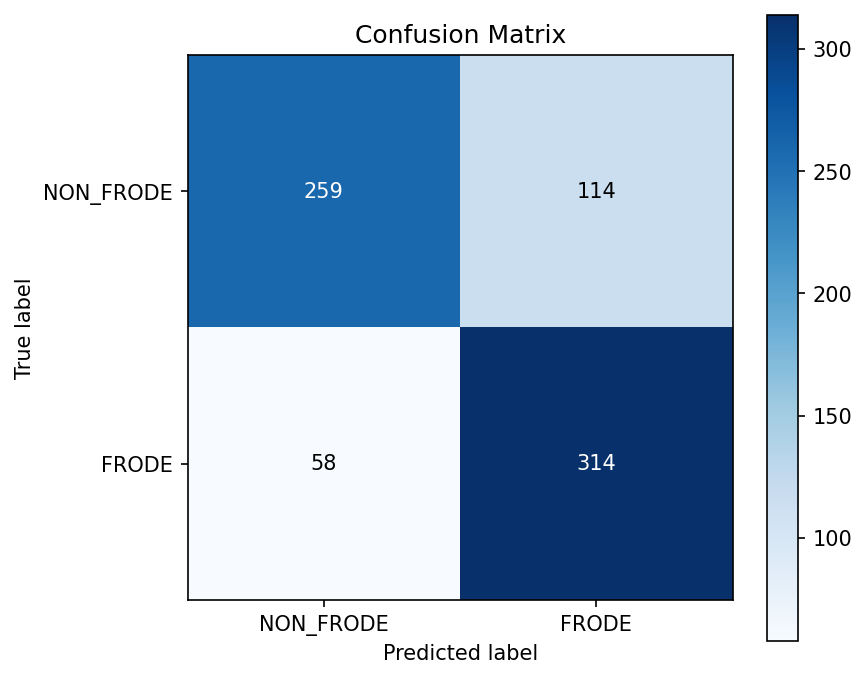


Probability Distributions:


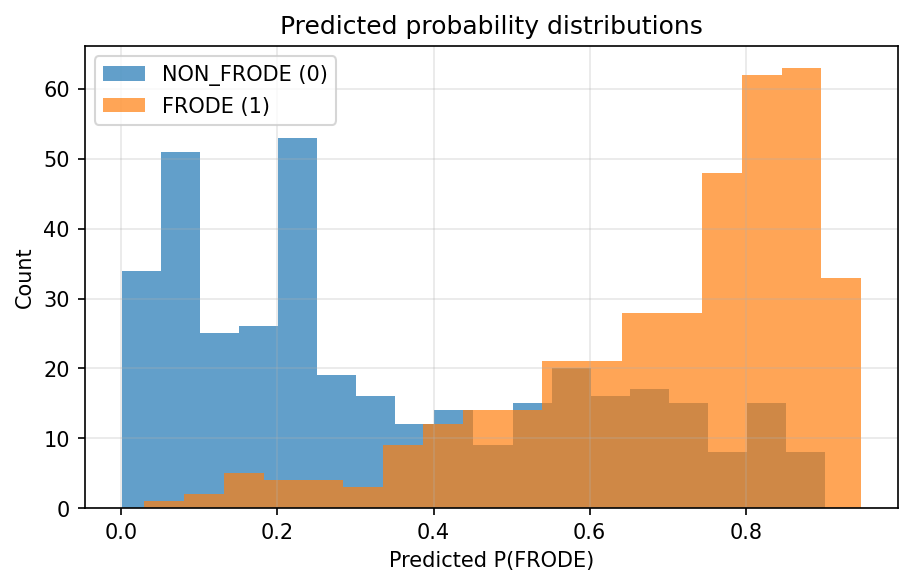


ROC Curve:


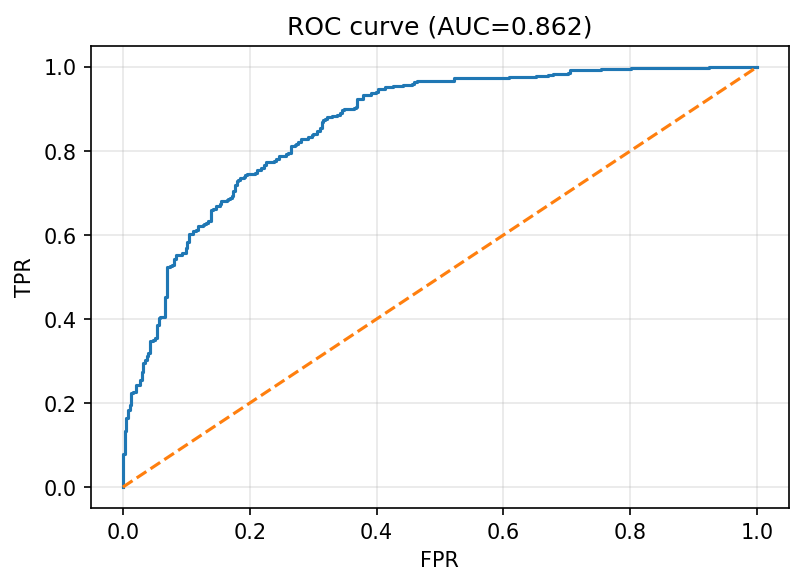


Precision-Recall Curve:


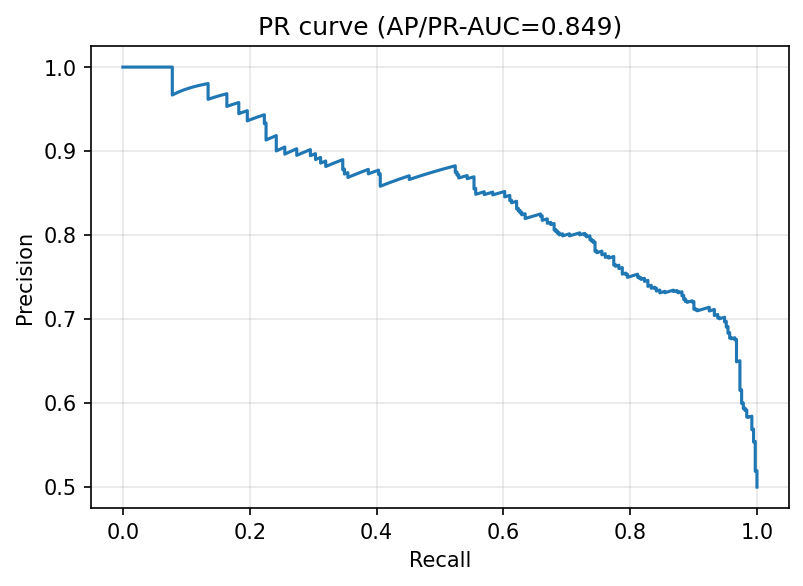

In [17]:
# Display metrics and visualizations inline
import json
import pandas as pd
from IPython.display import Image, display
from pathlib import Path

results_dir = Path(OUTPUT_DIR)

# Load metrics
with open(results_dir / "metrics.json") as f:
    metrics = json.load(f)

print("="*80)
print("TEST METRICS")
print("="*80)
for k, v in metrics['test_metrics'].items():
    if v is not None:
        print(f"{k:>15}: {v:.4f}")

# Confusion matrix
cm = metrics['confusion_matrix']
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)
print("              Predicted")
print("              NON_FRODE  FRODE")
print(f"True NON_FRODE    {cm[0][0]:>4}     {cm[0][1]:>4}   (FP: {cm[0][1]})")
print(f"True FRODE        {cm[1][0]:>4}     {cm[1][1]:>4}   (FN: {cm[1][0]})")

# Display plots
print("\n" + "="*80)
print("VISUALIZATIONS")
print("="*80)

print("\nConfusion Matrix:")
display(Image(filename=str(results_dir / "cm.png")))

print("\nProbability Distributions:")
display(Image(filename=str(results_dir / "prob_dist.png")))

print("\nROC Curve:")
display(Image(filename=str(results_dir / "roc_curve.png")))

print("\nPrecision-Recall Curve:")
display(Image(filename=str(results_dir / "pr_curve.png")))


In [ ]:
# Show performance by food category
food_metrics = pd.read_csv(results_dir / "group_metrics_food.csv")
food_sorted = food_metrics.sort_values('f1', ascending=False)

print("="*80)
print("PERFORMANCE BY FOOD CATEGORY")
print("="*80)
print(f"\n{'Food Category':<20} {'Samples':>8} {'F1':>6} {'Prec':>6} {'Rec':>6}")
print("-"*80)
for _, row in food_sorted.iterrows():
    print(f"{str(row['food_category']):<20} {row['n_samples']:>8} "
          f"{row['f1']:>6.3f} {row['precision']:>6.3f} {row['recall']:>6.3f}")

# Problematic categories
print("\n⚠️  Categories with F1 < 0.85:")
low_f1 = food_sorted[food_sorted['f1'] < 0.85]
if len(low_f1) > 0:
    for _, row in low_f1.iterrows():
        print(f"  - {row['food_category']}: F1={row['f1']:.3f}, "
              f"FP={int(row['fp'])}, FN={int(row['fn'])}")
else:
    print("  None! All categories have F1 >= 0.85 ✓")


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_food.csv'

In [18]:
# Show generator comparison
gen_metrics = pd.read_csv(results_dir / "group_metrics_generator.csv")

print("="*80)
print("GENERATOR COMPARISON")
print("="*80)
print(f"\n{'Generator':<25} {'Samples':>8} {'F1':>6} {'Precision':>10} {'Recall':>8}")
print("-"*80)
for _, row in gen_metrics.iterrows():
    print(f"{str(row['generator']):<25} {row['n_samples']:>8} "
          f"{row['f1']:>6.3f} {row['precision']:>10.3f} {row['recall']:>8.3f}")


GENERATOR COMPARISON

Generator                  Samples     F1  Precision   Recall
--------------------------------------------------------------------------------


In [19]:
# Show top false positives
fp = pd.read_csv(results_dir / "top_false_positives.csv")

print("="*80)
print("TOP 10 FALSE POSITIVES (Originali classified as Frodi)")
print("="*80)
print(f"\n{'Food':<15} {'Quality':<10} {'Defect':<15} {'Confidence':>10}")
print("-"*80)
for _, row in fp.head(10).iterrows():
    food = str(row.get('food_category', 'N/A'))[:14]
    quality = str(row.get('quality', 'N/A'))[:9]
    defect = str(row.get('defect_type', 'N/A'))[:14]
    conf = row['y_prob']
    print(f"{food:<15} {quality:<10} {defect:<15} {conf:>10.3f}")


TOP 10 FALSE POSITIVES (Originali classified as Frodi)

Food            Quality    Defect          Confidence
--------------------------------------------------------------------------------
nan             b0ae6581_  nan                  0.902
nan             56baabe5_  nan                  0.878
nan             375e1e7c_  nan                  0.871
nan             eea2c912_  nan                  0.863
nan             0d6e2aed_  nan                  0.861
nan             fa222473_  nan                  0.855
nan             61eb051a_  nan                  0.854
nan             157d46cb_  nan                  0.854
nan             61ebdb97_  nan                  0.851
nan             7be4451d_  nan                  0.850


In [20]:
# ============================================================================
# PHOTO-LEVEL ANALYSIS - Aggregate 8 versions per photo
# ============================================================================

#Cosa fa:

#Aggrega le 8 versioni per ogni foto (metriche più realistiche)
#Trova il threshold ottimale (probabilmente 0.850)
#Mostra il miglioramento rispetto al threshold di default (0.550)
#Analizza la consistenza delle predizioni tra versioni


print("="*80)
print("PHOTO-LEVEL ANALYSIS")
print("="*80)

!python scripts/analyze_by_photo.py \
    --run {OUTPUT_DIR} \
    --min-recall 0.90

# Display chosen threshold
import json
with open(f"{OUTPUT_DIR}/chosen_threshold.json", 'r') as f:
    threshold_info = json.load(f)

print("\n" + "="*80)
print("THRESHOLD RECOMMENDATION")
print("="*80)
print(f"🎯 Recommended threshold: {threshold_info['recommendation']:.3f}")
print(f"   F1-optimal threshold: {threshold_info['f1_optimal']:.3f}")
print(f"   Precision-optimal (recall≥90%): {threshold_info['precision_optimal_recall_90']:.3f}")
print(f"\nRationale: {threshold_info['rationale']}")

# Display photo-level metrics
with open(f"{OUTPUT_DIR}/photo_level_metrics.json", 'r') as f:
    photo_metrics = json.load(f)

print("\n" + "="*80)
print("PHOTO-LEVEL METRICS (aggregated by photo)")
print("="*80)
print(f"Total photos: {photo_metrics['n_photos']}")

print("\nOriginal threshold (0.550):")
orig = photo_metrics['original_threshold']
print(f"  Precision: {orig['precision']:.1%}")
print(f"  Recall:    {orig['recall']:.1%}")
print(f"  F1:        {orig['f1']:.1%}")
print(f"  FP: {orig['fp']}, FN: {orig['fn']}")

print(f"\nOptimal threshold ({threshold_info['recommendation']:.3f}):")
opt = photo_metrics['optimal_f1_threshold']
print(f"  Precision: {opt['precision']:.1%} ({opt['precision']-orig['precision']:+.1%})")
print(f"  Recall:    {opt['recall']:.1%} ({opt['recall']-orig['recall']:+.1%})")
print(f"  F1:        {opt['f1']:.1%} ({opt['f1']-orig['f1']:+.1%})")
print(f"  FP: {opt['fp']} ({int(opt['fp']-orig['fp']):+d}), FN: {opt['fn']} ({int(opt['fn']-orig['fn']):+d})")

print("\nConsistency (std of 8 versions per photo):")
cons = photo_metrics['consistency']
print(f"  Photos with std < 0.05: {cons['pct_std_lt_0.05']:.1f}%")
print(f"  Median std: {cons['median_std']:.6f}")
print(f"  Average std: {cons['avg_std']:.4f}")

print("\n✓ Photo-level analysis complete")


PHOTO-LEVEL ANALYSIS
PHOTO-LEVEL ANALYSIS
Run: 2026-03-13_noise_high_pass
Aggregation: mean

Image-level: 745 images
Original threshold: 0.500

AGGREGATING BY PHOTO

⚠️  WARNING: 366 photos have inconsistent labels!
   This indicates a bug in dataset construction.
   Examples: ['0087', '0178', '01a1', '0314', '035d']
Photo-level: 369 unique photos
  Positive: 185
  Negative: 184
  Avg versions per photo: 2.02

METRICS AT ORIGINAL THRESHOLD (0.500)

Photo-level metrics:
  Accuracy:  0.5122
  Precision: 0.5135
  Recall:    0.5135
  F1:        0.5135
  ROC-AUC:   0.5418
  PR-AUC:    0.5462

Confusion Matrix:
  TN=94  FP=90
  FN=90  TP=95

THRESHOLD OPTIMIZATION

Optimal threshold (F1): 0.150
  F1: 0.6679
  Accuracy:  0.5068
  Precision: 0.5041
  Recall:    0.9892
  FP: 180, FN: 2

Precision-optimized threshold (recall >= 0.90): 0.300
  Precision: 0.5163
  Recall:    0.9405
  F1:        0.6667
  FP: 163, FN: 11

CONSISTENCY ANALYSIS

Probability std across versions:
  Mean:   0.2803
  Medi

In [ ]:
# ============================================================================
# TEMPERATURE SCALING CALIBRATION - Reduce overconfidence
# ============================================================================
print("="*80)
print("TEMPERATURE SCALING CALIBRATION")
print("="*80)

!python scripts/apply_calibration.py \
    --run {OUTPUT_DIR}

# Display calibration results
import json

# Load temperature from calibration_T.json
with open(f"{OUTPUT_DIR}/calibration_T.json", 'r') as f:
    cal_T = json.load(f)

# Load report from calibration_report.json
with open(f"{OUTPUT_DIR}/calibration_report.json", 'r') as f:
    cal_report = json.load(f)

print("\n" + "="*80)
print("CALIBRATION RESULTS")
print("="*80)
print(f"📊 Optimal temperature: T = {cal_T['temperature']:.4f}")

print("\nExpected Calibration Error (lower is better):")
print(f"  Before calibration: {cal_report['ece_before']:.4f}")
print(f"  After calibration:  {cal_report['ece_after']:.4f}")
print(f"  Improvement: {cal_report['ece_improvement']:.4f}")

print("\nOverconfident negatives (prob>0.95 but y=0):")
print(f"  Before: {cal_report['overconfident_negatives_before']}")
print(f"  After:  {cal_report['overconfident_negatives_after']}")
print(f"  Reduction: {cal_report['overconfident_negatives_before'] - cal_report['overconfident_negatives_after']}")

# Display updated photo-level metrics
with open(f"{OUTPUT_DIR}/photo_level_metrics.json", 'r') as f:
    photo_metrics = json.load(f)

print("\n" + "="*80)
print("PHOTO-LEVEL METRICS (after calibration)")
print("="*80)

with open(f"{OUTPUT_DIR}/chosen_threshold.json", 'r') as f:
    threshold_info = json.load(f)

print(f"Updated threshold: {threshold_info['recommendation']:.3f}")

opt = photo_metrics['optimal_f1_threshold']
print(f"\nCalibrated metrics:")
print(f"  Precision: {opt['precision']:.1%}")
print(f"  Recall:    {opt['recall']:.1%}")
print(f"  F1:        {opt['f1']:.1%}")
print(f"  FP: {opt['fp']}, FN: {opt['fn']}")

print("\n✓ Calibration complete")


TEMPERATURE SCALING CALIBRATION
TEMPERATURE SCALING CALIBRATION
Run: 2026-02-18_convnext_v7_noLeakage

Loading validation data...
  Validation samples: 616

Optimizing temperature...

Temperature Calibration:
  Initial T: 1.0000
  Optimal T: 1.0000
  NLL (before): 0.3856
  NLL (after):  0.3856

✓ Saved: outputs/runs/2026-02-18_convnext_v7_noLeakage/calibration_T.json

Applying calibration to test set...

Calibration Report:
  ECE before: 0.1327
  ECE after:  0.1327
  Improvement: 0.0000

  Overconfident negatives (prob>0.95 but y=0):
    Before: 1
    After:  1
    Reduction: 0

✓ Saved: outputs/runs/2026-02-18_convnext_v7_noLeakage/predictions_calibrated.csv
✓ Saved: outputs/runs/2026-02-18_convnext_v7_noLeakage/calibration_report.json

RE-RUNNING PHOTO-LEVEL ANALYSIS WITH CALIBRATED PROBABILITIES
PHOTO-LEVEL ANALYSIS
Run: 2026-02-18_convnext_v7_noLeakage
Aggregation: mean

Image-level: 616 images
Original threshold: 0.700

AGGREGATING BY PHOTO
Photo-level: 77 unique photos
  Positive

In [ ]:
# ============================================================================
# HARD NEGATIVE FINE-TUNING (OPTIONAL - only if precision < 75%)
# ============================================================================
print("="*80)
print("HARD NEGATIVE FINE-TUNING CHECK")
print("="*80)

# Check if we need hard negative mining
import json
import os

with open(f"{OUTPUT_DIR}/photo_level_metrics.json", 'r') as f:
    photo_metrics = json.load(f)

current_precision = photo_metrics['optimal_f1_threshold']['precision']
print(f"Current precision: {current_precision:.1%}")

PRECISION_THRESHOLD = 0.75
RUN_HARD_NEGATIVE = current_precision < PRECISION_THRESHOLD

if RUN_HARD_NEGATIVE:
    print(f"\n⚠️  Precision < {PRECISION_THRESHOLD:.0%} → Running hard negative fine-tuning")
    print("This will fine-tune on 17 problematic photos (systematic FPs)")

    # Run hard negative mining
    !python scripts/hard_negative_finetune.py \
        --run {OUTPUT_DIR} \
        --config {CONFIG_PATH} \
        --checkpoint_dir {CHECKPOINT_DIR} \
        --epochs 5 \
        --lr 1e-5 \
        --repeat_factor 3 \
        --output_suffix _hard_negative

    # New run name
    HN_RUN_NAME = f"{EXPERIMENT_NAME}_hard_negative"
    HN_OUTPUT_DIR = f"outputs/runs/{HN_RUN_NAME}"

    # Check if hard negative training completed
    if os.path.exists(f"{HN_OUTPUT_DIR}/photo_level_metrics.json"):
        print("\n" + "="*80)
        print("HARD NEGATIVE RESULTS")
        print("="*80)

        # Display comparison
        with open(f"{HN_OUTPUT_DIR}/photo_level_metrics.json", 'r') as f:
            hn_metrics = json.load(f)

        hn_opt = hn_metrics['optimal_f1_threshold']

        print(f"\nBefore hard negative mining:")
        print(f"  Precision: {current_precision:.1%}")
        print(f"  Recall:    {photo_metrics['optimal_f1_threshold']['recall']:.1%}")
        print(f"  F1:        {photo_metrics['optimal_f1_threshold']['f1']:.1%}")

        print(f"\nAfter hard negative mining:")
        print(f"  Precision: {hn_opt['precision']:.1%} ({hn_opt['precision']-current_precision:+.1%})")
        print(f"  Recall:    {hn_opt['recall']:.1%}")
        print(f"  F1:        {hn_opt['f1']:.1%}")

        print(f"\n✓ Hard negative fine-tuning complete")
        print(f"  New run: {HN_OUTPUT_DIR}")

        # Update backup directory
        HN_BACKUP_DIR = f"/content/drive/MyDrive/verifoto_results/{HN_RUN_NAME}"
    else:
        print(f"\n❌ Hard negative fine-tuning failed - check errors above")
        HN_RUN_NAME = None
        HN_OUTPUT_DIR = None
        HN_BACKUP_DIR = None
else:
    print(f"\n✓ Precision ≥ {PRECISION_THRESHOLD:.0%} → Skipping hard negative fine-tuning")
    print("Model performance is already good enough!")
    HN_RUN_NAME = None
    HN_OUTPUT_DIR = None
    HN_BACKUP_DIR = None

print("\n" + "="*80)


HARD NEGATIVE FINE-TUNING CHECK
Current precision: 70.8%

⚠️  Precision < 75% → Running hard negative fine-tuning
This will fine-tune on 17 problematic photos (systematic FPs)
usage: hard_negative_finetune.py [-h] --run RUN --config CONFIG
                                 [--epochs EPOCHS] [--lr LR]
                                 [--repeat_factor REPEAT_FACTOR]
                                 [--output_suffix OUTPUT_SUFFIX]
hard_negative_finetune.py: error: unrecognized arguments: --checkpoint_dir /content/drive/MyDrive/verifoto_checkpoints

❌ Hard negative fine-tuning failed - check errors above



---
## 💾 BACKUP & SYNC


In [21]:
# ============================================================================
# BACKUP RESULTS TO GOOGLE DRIVE
# ============================================================================
import shutil

print("="*80)
print("BACKING UP RESULTS TO DRIVE")
print("="*80)

# Backup main run
print(f"\nBacking up main run: {BACKUP_DIR}")
!mkdir -p {BACKUP_DIR}
!cp -r {OUTPUT_DIR}/* {BACKUP_DIR}/
print("✓ Main run backup complete")

# Backup hard negative run if it exists
if 'HN_BACKUP_DIR' in locals() and HN_BACKUP_DIR is not None:
    print(f"\nBacking up hard negative run: {HN_BACKUP_DIR}")
    !mkdir -p {HN_BACKUP_DIR}
    !cp -r {HN_OUTPUT_DIR}/* {HN_BACKUP_DIR}/
    print("✓ Hard negative run backup complete")

print("\n✓ All backups complete")



BACKING UP RESULTS TO DRIVE

Backing up main run: /content/drive/MyDrive/verifoto_results/2026-03-13_noise_high_pass
✓ Main run backup complete

✓ All backups complete


In [6]:
!ls configs

baseline.yaml		  convnext_v7_improved.yaml   quick_test.yaml
convnext_experiment.yaml  convnext_v8.yaml
convnext_v7_fast.yaml	  domain_aware_baseline.yaml


# Test con dataset esterno - AntiLeakage

In [7]:
# ============================================================================
# EXTERNAL TEST - Test su dataset holdout (anche da checkpoint salvato su Drive)
# ============================================================================

import os
import json
from pathlib import Path


# =========================
# CONFIG
# =========================

# Se True, usa checkpoint e metriche della run attuale
# Se False, usa file specificati manualmente sotto
USE_CURRENT_RUN = False

# Dataset esterno da testare
EXTERNAL_DATASET = "/content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK_highpass"



# ----- Modalità manuale (quando USE_CURRENT_RUN = False) -----
MANUAL_EXPERIMENT_NAME = "2026-03-13_convnext_v8_highpass"
MANUAL_CHECKPOINT_PATH = "/content/drive/MyDrive/verifoto_checkpoints/2026-03-13_noise_high_pass/best.pt"
MANUAL_METRICS_PATH = "/content/drive/MyDrive/verifoto_results/2026-03-13_noise_high_pass/metrics.json"

# Se non vuoi leggere il threshold da metrics.json, impostalo qui
MANUAL_THRESHOLD = 0.5   # es. 0.5 oppure None

# Config del progetto
CONFIG_PATH_MANUAL = "configs/convnext_v8.yaml"   # cambia se il tuo path è diverso

print("=" * 80)
print("EXTERNAL TEST")
print("=" * 80)

# Vai nella root del progetto
%cd /content/verifoto-dl

# Controllo dataset esterno
if not os.path.exists(EXTERNAL_DATASET):
    raise FileNotFoundError(f"Dataset esterno non trovato: {EXTERNAL_DATASET}")

# =========================
# RISOLUZIONE PATH E PARAMETRI
# =========================
if USE_CURRENT_RUN:
    print("Modalità: CURRENT RUN")

    checkpoint_path = f"{CHECKPOINT_DIR}/{EXPERIMENT_NAME}/best.pt"
    metrics_path = f"{OUTPUT_DIR}/metrics.json"
    config_path = CONFIG_PATH
    run_name_base = EXPERIMENT_NAME

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint non trovato: {checkpoint_path}")

    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            train_metrics = json.load(f)
        optimal_threshold = train_metrics.get("threshold", 0.5)
    else:
        print(f"⚠️ metrics.json non trovato in {metrics_path}, uso threshold=0.5")
        optimal_threshold = 0.5

else:
    print("Modalità: MANUAL / DRIVE CHECKPOINT")

    checkpoint_path = MANUAL_CHECKPOINT_PATH
    metrics_path = MANUAL_METRICS_PATH
    config_path = CONFIG_PATH_MANUAL
    run_name_base = MANUAL_EXPERIMENT_NAME

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint non trovato: {checkpoint_path}")

    if MANUAL_THRESHOLD is not None:
        optimal_threshold = MANUAL_THRESHOLD
        print(f"Uso threshold manuale: {optimal_threshold}")
    else:
        if not os.path.exists(metrics_path):
            raise FileNotFoundError(
                f"metrics.json non trovato: {metrics_path}\n"
                f"Specifica MANUAL_THRESHOLD oppure fornisci un metrics.json valido."
            )
        with open(metrics_path, "r") as f:
            saved_metrics = json.load(f)
        optimal_threshold = saved_metrics.get("threshold", 0.5)

EXTERNAL_RUN_NAME = f"{run_name_base}_external"

print(f"External dataset : {EXTERNAL_DATASET}")
print(f"Checkpoint path  : {checkpoint_path}")
print(f"Config path      : {config_path}")
print(f"Threshold        : {optimal_threshold:.4f}")
print(f"Run name         : {EXTERNAL_RUN_NAME}")

# =========================
# RUN EVAL
# =========================
!python -m src.eval \
    --config {config_path} \
    --run_name {EXTERNAL_RUN_NAME} \
    --checkpoint_path {checkpoint_path} \
    --threshold {optimal_threshold} \
    --external_test_dataset {EXTERNAL_DATASET}

# =========================
# BACKUP RISULTATI
# =========================
external_metrics_path = f"outputs/runs/{EXTERNAL_RUN_NAME}/metrics.json"

if os.path.exists(external_metrics_path):
    EXTERNAL_BACKUP_DIR = f"/content/drive/MyDrive/verifoto_results/{EXTERNAL_RUN_NAME}"
    !mkdir -p {EXTERNAL_BACKUP_DIR}
    !cp -r outputs/runs/{EXTERNAL_RUN_NAME}/* {EXTERNAL_BACKUP_DIR}/

    print(f"\n✓ External test complete: outputs/runs/{EXTERNAL_RUN_NAME}")
    print(f"✓ Backup saved to: {EXTERNAL_BACKUP_DIR}")
else:
    print(f"\n❌ External test failed - check errors above")


EXTERNAL TEST
/content/verifoto-dl
Modalità: MANUAL / DRIVE CHECKPOINT
Uso threshold manuale: 0.5
External dataset : /content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK_highpass
Checkpoint path  : /content/drive/MyDrive/verifoto_checkpoints/2026-03-13_noise_high_pass/best.pt
Config path      : configs/convnext_v8.yaml
Threshold        : 0.5000
Run name         : 2026-03-13_convnext_v8_highpass_external
Device: cuda
Checkpoint: /content/drive/MyDrive/verifoto_checkpoints/2026-03-13_noise_high_pass/best.pt
Output: outputs/runs/2026-03-13_convnext_v8_highpass_external

EXTERNAL TEST MODE
External test dataset: /content/drive/MyDrive/DatasetVerifoto/images/exp_3_augmented_v6.2_noK_highpass
⚠️  This dataset is COMPLETELY SEPARATE from training data
   No internal split - using entire dataset as test set
                                                           
Dataset caricato: 4088 immagini
  - Originali (label=0): 1432
  - Modificate (label=1): 2656
  - Food categorie

In [ ]:
# ============================================================================
# EXTERNAL TEST: PHOTO-LEVEL ANALYSIS & CALIBRATION
# ============================================================================

EXTERNAL_RUN_NAME = f"{EXPERIMENT_NAME}_external"
EXTERNAL_OUTPUT_DIR = f"outputs/runs/{EXTERNAL_RUN_NAME}"

if os.path.exists(f"{EXTERNAL_OUTPUT_DIR}/metrics.json"):
    print("="*80)
    print("EXTERNAL TEST: PHOTO-LEVEL ANALYSIS")
    print("="*80)

    # Photo-level analysis
    !python scripts/analyze_by_photo.py \
        --run {EXTERNAL_OUTPUT_DIR} \
        --min-recall 0.90

    # Display chosen threshold
    if os.path.exists(f"{EXTERNAL_OUTPUT_DIR}/chosen_threshold.json"):
        import json
        with open(f"{EXTERNAL_OUTPUT_DIR}/chosen_threshold.json", 'r') as f:
            threshold_info = json.load(f)

        print("\n" + "="*80)
        print("EXTERNAL TEST: THRESHOLD RECOMMENDATION")
        print("="*80)
        print(f"🎯 Recommended threshold: {threshold_info['recommendation']:.3f}")
        print(f"   F1-optimal threshold: {threshold_info['f1_optimal']:.3f}")
        print(f"   Precision-optimal (recall≥90%): {threshold_info['precision_optimal_recall_90']:.3f}")
        print(f"\nRationale: {threshold_info['rationale']}")

        # Display photo-level metrics
        with open(f"{EXTERNAL_OUTPUT_DIR}/photo_level_metrics.json", 'r') as f:
            photo_metrics = json.load(f)

        print("\n" + "="*80)
        print("EXTERNAL TEST: PHOTO-LEVEL METRICS")
        print("="*80)
        print(f"Total photos: {photo_metrics['n_photos']}")

        print("\nOriginal threshold (from training):")
        orig = photo_metrics['original_threshold']
        print(f"  Threshold: {orig['threshold']:.3f}")
        print(f"  Precision: {orig['precision']:.1%}")
        print(f"  Recall:    {orig['recall']:.1%}")
        print(f"  F1:        {orig['f1']:.1%}")
        print(f"  FP: {orig['fp']}, FN: {orig['fn']}")

        print(f"\nOptimal threshold for external ({threshold_info['recommendation']:.3f}):")
        opt = photo_metrics['optimal_f1_threshold']
        print(f"  Precision: {opt['precision']:.1%} ({opt['precision']-orig['precision']:+.1%})")
        print(f"  Recall:    {opt['recall']:.1%} ({opt['recall']-orig['recall']:+.1%})")
        print(f"  F1:        {opt['f1']:.1%} ({opt['f1']-orig['f1']:+.1%})")
        print(f"  FP: {opt['fp']} ({int(opt['fp']-orig['fp']):+d}), FN: {opt['fn']} ({int(opt['fn']-orig['fn']):+d})")

        print("\n✓ External photo-level analysis complete")

    # Temperature scaling calibration (copy from training)
    print("\n" + "="*80)
    print("EXTERNAL TEST: CALIBRATION")
    print("="*80)
    print("⚠️  Note: External test uses model calibrated on internal validation data")
    print("    Calibration parameters from training run are already applied.")

    # Copy calibration files from training run
    import shutil
    training_cal_T = f"{OUTPUT_DIR}/calibration_T.json"
    training_cal_report = f"{OUTPUT_DIR}/calibration_report.json"

    if os.path.exists(training_cal_T):
        shutil.copy(training_cal_T, f"{EXTERNAL_OUTPUT_DIR}/calibration_T.json")
        print(f"✓ Copied calibration_T.json from training run")

    if os.path.exists(training_cal_report):
        shutil.copy(training_cal_report, f"{EXTERNAL_OUTPUT_DIR}/calibration_report.json")
        print(f"✓ Copied calibration_report.json from training run")

    print("\n✓ External test analysis complete")
    print("="*80)
else:
    print("\n⚠️  External test not found - skipping analysis")

In [ ]:
# ============================================================================
# PUSH RESULTS TO GITHUB
# ============================================================================
import os
from getpass import getpass

# Get GitHub token if not set
if not GITHUB_TOKEN:
    print("GitHub token not set in configuration.")
    GITHUB_TOKEN = getpass("Enter your GitHub Personal Access Token (or press Enter to skip): ")

if GITHUB_TOKEN:
    %cd /content/verifoto-dl

    # Configure git
    !git config user.email "colab@verifoto.ai"
    !git config user.name "Colab Training"

    # Add main run results (force to override .gitignore)
    !git add -f {OUTPUT_DIR}

    # Add hard negative run if it exists
    if 'HN_OUTPUT_DIR' in locals() and HN_OUTPUT_DIR is not None:
        !git add -f {HN_OUTPUT_DIR}

    # Add external test results
    EXTERNAL_RUN_NAME = f"{EXPERIMENT_NAME}_external"
    if os.path.exists(f"outputs/runs/{EXTERNAL_RUN_NAME}"):
        !git add -f outputs/runs/{EXTERNAL_RUN_NAME}


    # Commit
    if 'HN_RUN_NAME' in locals() and HN_RUN_NAME is not None:
        commit_msg = f"Add training results: {EXPERIMENT_NAME} + {HN_RUN_NAME}"
    else:
        commit_msg = f"Add training results: {EXPERIMENT_NAME}"

    !git commit -m "{commit_msg}"

    # Push
    repo_url = f"https://{GITHUB_TOKEN}@github.com/valerio-lorenti-ai/verifoto-dl.git"
    !git push {repo_url} main

    print("\n✓ Results pushed to GitHub")
    print(f"  Main run: {OUTPUT_DIR}")
    if 'HN_OUTPUT_DIR' in locals() and HN_OUTPUT_DIR is not None:
        print(f"  Hard negative run: {HN_OUTPUT_DIR}")
else:
    print("\n⚠️  Skipping GitHub push (no token provided)")
    print("Results are backed up to Drive and available locally.")



/content/verifoto-dl
[main f4f4a49] Add training results: 2026-02-18_convnext_v7_noLeakage
 38 files changed, 2552 insertions(+)
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/calibration_T.json
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/calibration_report.json
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/chosen_threshold.json
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/cm.png
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_defect_type.csv
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_food_category.csv
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_generator.csv
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/group_metrics_quality.csv
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/metrics.json
 create mode 100644 outputs/runs/2026-02-18_convnext_v7_noLeakage/notes.md
 

---
## ✅ COMPLETION SUMMARY


In [29]:
# ============================================================================
# TRAINING PIPELINE COMPLETE
# ============================================================================
import os

print("="*80)
print("TRAINING PIPELINE COMPLETE")
print("="*80)

print(f"\nExperiment: {EXPERIMENT_NAME}")
print(f"Dataset: {DATASET_NAME}")

print(f"\nResults locations:")
print(f"  Local: {OUTPUT_DIR}")
print(f"  Drive backup: {BACKUP_DIR}")
print(f"  Checkpoint: {CHECKPOINT_DIR}/{EXPERIMENT_NAME}/best.pt")

# Check if external test was run
EXTERNAL_RUN_NAME = f"{EXPERIMENT_NAME}_external"
EXTERNAL_OUTPUT_DIR = f"outputs/runs/{EXTERNAL_RUN_NAME}"

if os.path.exists(EXTERNAL_OUTPUT_DIR):
    EXTERNAL_BACKUP_DIR = f"/content/drive/MyDrive/verifoto_results/{EXTERNAL_RUN_NAME}"
    print(f"\nExternal test:")
    print(f"  Local: {EXTERNAL_OUTPUT_DIR}")
    print(f"  Drive backup: {EXTERNAL_BACKUP_DIR}")

print(f"\nNext steps:")
print(f"  1. Review metrics and visualizations above")
print(f"  2. Pull results from GitHub to local machine:")
print(f"     git pull origin main")
print(f"  3. Analyze locally:")
print(f"     python scripts/analyze_results.py {EXPERIMENT_NAME}")

if os.path.exists(EXTERNAL_OUTPUT_DIR):
    print(f"  4. Compare internal vs external test:")
    print(f"     python scripts/compare_internal_external.py \\")
    print(f"       --internal outputs/runs/{EXPERIMENT_NAME} \\")
    print(f"       --external outputs/runs/{EXTERNAL_RUN_NAME}")

print("\n" + "="*80)


TRAINING PIPELINE COMPLETE

Experiment: 2026-03-13_noise_high_pass
Dataset: whatsapp_Luca

Results locations:
  Local: outputs/runs/2026-03-13_noise_high_pass
  Drive backup: /content/drive/MyDrive/verifoto_results/2026-03-13_noise_high_pass
  Checkpoint: /content/drive/MyDrive/verifoto_checkpoints/2026-03-13_noise_high_pass/best.pt

External test:
  Local: outputs/runs/2026-03-13_noise_high_pass_external
  Drive backup: /content/drive/MyDrive/verifoto_results/2026-03-13_noise_high_pass_external

Next steps:
  1. Review metrics and visualizations above
  2. Pull results from GitHub to local machine:
     git pull origin main
  3. Analyze locally:
     python scripts/analyze_results.py 2026-03-13_noise_high_pass
  4. Compare internal vs external test:
     python scripts/compare_internal_external.py \
       --internal outputs/runs/2026-03-13_noise_high_pass \
       --external outputs/runs/2026-03-13_noise_high_pass_external

